# 🏷️ Classification supervisée des marchés Polymarket

**Objectif** : Entraîner un classifieur TF-IDF + Logistic Regression sur 500 marchés labélisés, puis prédire les catégories des ~538K marchés restants.

**Pipeline** : `labeled_500.csv` → TF-IDF → LogReg → prédictions 538K → BigQuery

---

## Étape 1 — Setup et upload

In [1]:
# Upload du fichier labélisé
from google.colab import files
uploaded = files.upload()  # → sélectionner labeled_500.csv

Saving labeled_500.csv to labeled_500.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns

## Étape 2 — Charger les données

In [3]:
# Charger le training set
labeled = pd.read_csv('labeled_500.csv')
print(f"Training set: {len(labeled)} marchés, {labeled['label'].nunique()} catégories")
print(labeled['label'].value_counts())

Training set: 500 marchés, 15 catégories
label
Sports            222
US Politics        69
Crypto Price       63
Geopolitics        49
Macroeconomy       25
Esports            21
Social Media       11
AI/Tech             9
Crypto Up/Down      8
Stocks/Finance      7
Other               6
Cinema/TV           5
Music               3
Press People        1
Weather             1
Name: count, dtype: int64


In [4]:
# Charger les 538K marchés depuis BigQuery
from google.colab import auth
auth.authenticate_user()

client = bigquery.Client(project='polymarket-research-490517')

# D'abord vérifier les colonnes disponibles
query = """SELECT column_name
FROM `polymarket-research-490517.polymarket.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'markets'"""
print(client.query(query).to_dataframe().to_string())

       column_name
0               id
1         question
2             slug
3     condition_id
4           token1
5           token2
6          answer1
7          answer2
8           closed
9           active
10        archived
11  outcome_prices
12          volume
13        event_id
14      event_slug
15     event_title
16      created_at
17        end_date
18      updated_at
19        neg_risk


In [5]:
# Récupérer les marchés (adapter le nom de colonne si nécessaire)
query = """
SELECT question, slug, event_slug
FROM `polymarket-research-490517.polymarket.markets`
WHERE question IS NOT NULL
"""
all_markets = client.query(query).to_dataframe()
print(f"Total marchés: {len(all_markets)}")
all_markets.head()

Total marchés: 607561


,question,slug,event_slug
0,Counter-Strike: CSDIILIT vs Bushido Wildcats ...,cs2-csdiil-bw-2026-03-16,cs2-csdiil-bw-2026-03-16
1,Counter-Strike: CSDIILIT vs Bushido Wildcats ...,cs2-csdiil-bw-2026-03-16-game1,cs2-csdiil-bw-2026-03-16
2,Counter-Strike: CSDIILIT vs Bushido Wildcats ...,cs2-csdiil-bw-2026-03-16-game2,cs2-csdiil-bw-2026-03-16
3,Map Handicap: CSDIILIT (-1.5) vs QUAZAR (+1.5),cs2-qua1-csdiil-2026-03-05-map-handicap-home-1pt5,cs2-qua1-csdiil-2026-03-05
4,Counter-Strike: CSDIILIT vs HEROIC Academy - ...,cs2-csdiil-heroa-2026-03-06-game1,cs2-csdiil-heroa-2026-03-06


> ⚠️ Si la colonne ne s'appelle pas `question`, adapte avec le nom trouvé ci-dessus (peut-être `title` ou `market_question`).

## Étape 3 — TF-IDF + Entraînement

In [6]:
# Fit TF-IDF sur TOUTES les questions (labeled + unlabeled)
# → le vocabulaire couvre tout le corpus
all_questions = pd.concat([
    labeled['question'],
    all_markets['question']
]).reset_index(drop=True)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=2,
    stop_words='english',
    sublinear_tf=True,        # log(1 + tf), meilleur pour la classification
)

tfidf.fit(all_questions)

X_train = tfidf.transform(labeled['question'])
y_train = labeled['label']

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"X_train shape: {X_train.shape}")

Vocabulary size: 10000
X_train shape: (500, 10000)


In [7]:
# Cross-validation pour évaluer avant de prédire
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # compense le déséquilibre (Sports dominant)
    C=1.0,
)

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"F1 macro (5-fold CV): {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Per fold: {[f'{s:.3f}' for s in scores]}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


F1 macro (5-fold CV): 0.588 ± 0.083
Per fold: ['0.705', '0.668', '0.503', '0.507', '0.559']


> ✅ **Check** : vise un F1 macro > 0.80 pour que ce soit fiable. Si c'est en dessous, on ajuste.

In [8]:
# Entraîner le modèle final sur tout le training set
model.fit(X_train, y_train)

# Sanity check sur le train (pas une vraie évaluation)
train_pred = model.predict(X_train)
print(classification_report(y_train, train_pred))

                precision    recall  f1-score   support

       AI/Tech       0.82      1.00      0.90         9
     Cinema/TV       1.00      1.00      1.00         5
  Crypto Price       1.00      0.94      0.97        63
Crypto Up/Down       0.80      1.00      0.89         8
       Esports       1.00      1.00      1.00        21
   Geopolitics       1.00      0.96      0.98        49
  Macroeconomy       0.96      1.00      0.98        25
         Music       1.00      1.00      1.00         3
         Other       0.75      1.00      0.86         6
  Press People       1.00      1.00      1.00         1
  Social Media       1.00      1.00      1.00        11
        Sports       1.00      1.00      1.00       222
Stocks/Finance       1.00      1.00      1.00         7
   US Politics       0.97      0.94      0.96        69
       Weather       1.00      1.00      1.00         1

      accuracy                           0.98       500
     macro avg       0.95      0.99      0.97 

## Étape 4 — Prédire sur les 538K marchés

In [9]:
X_all = tfidf.transform(all_markets['question'])
all_markets['predicted_label'] = model.predict(X_all)
all_markets['confidence'] = model.predict_proba(X_all).max(axis=1)

print("Distribution des catégories prédites:")
print(all_markets['predicted_label'].value_counts())
print(f"\nConfidence moyenne: {all_markets['confidence'].mean():.3f}")
print(f"Confidence médiane: {all_markets['confidence'].median():.3f}")

Distribution des catégories prédites:
predicted_label
Sports            398669
Crypto Price       81346
Esports            49309
Crypto Up/Down     36371
US Politics        11657
Geopolitics         9624
Social Media        4995
Stocks/Finance      3868
AI/Tech             3694
Cinema/TV           2243
Macroeconomy        2096
Other               1287
Music               1197
Weather             1016
Press People         189
Name: count, dtype: int64

Confidence moyenne: 0.178
Confidence médiane: 0.162


## Étape 5 — Validation visuelle

In [10]:
# Spot-check : pour chaque catégorie, les 5 plus et moins confiants
for cat in sorted(all_markets['predicted_label'].unique()):
    subset = all_markets[all_markets['predicted_label'] == cat].sort_values('confidence')
    print(f"\n{'='*60}")
    print(f"  {cat} ({len(subset)} marchés)")
    print(f"{'='*60}")
    print("  ⬇ LEAST confident:")
    for _, row in subset.head(5).iterrows():
        print(f"    [{row['confidence']:.2f}] {row['question'][:80]}")
    print("  ⬆ MOST confident:")
    for _, row in subset.tail(5).iterrows():
        print(f"    [{row['confidence']:.2f}] {row['question'][:80]}")


  AI/Tech (3694 marchés)
  ⬇ LEAST confident:
    [0.11] $SPX6900 all time high by Jan 31?
    [0.11] Ethereum all time high in June?
    [0.11] $GME all time high in June?
    [0.11] Will the highest temperature in New York City be between 30-31°F on January 21?
    [0.11] Will no vote occur on a new funding bill by October 31?
  ⬆ MOST confident:
    [0.74] Will OpenAI have the top AI model on June 30?
    [0.74] Will OpenAI have a #1 AI model by June 30?
    [0.76] Will Z.ai have the top AI model on December 31?
    [0.76] Will Mistral AI have the top AI model on December 31?
    [0.76] Will Z.ai have a #1 AI model by June 30?

  Cinema/TV (2243 marchés)
  ⬇ LEAST confident:
    [0.11] Will Michelangelo Dying (Cate Le Bon) be the #1 album on Rolling Stone's 100 Bes
    [0.11] Will "Goodbye June" be the #2 global Netflix movie this week? (December 30, 2025
    [0.11] Will "Goodbye June" be the top global Netflix movie this week? (December 30, 202
    [0.11] Will Adam Sandler - The P

> 🔍 **C'est l'étape la plus importante.** Les "least confident" sont les cas limites — vérifie s'ils sont mal classés. Si une catégorie a beaucoup d'erreurs, ajoute quelques exemples au training set et relance.

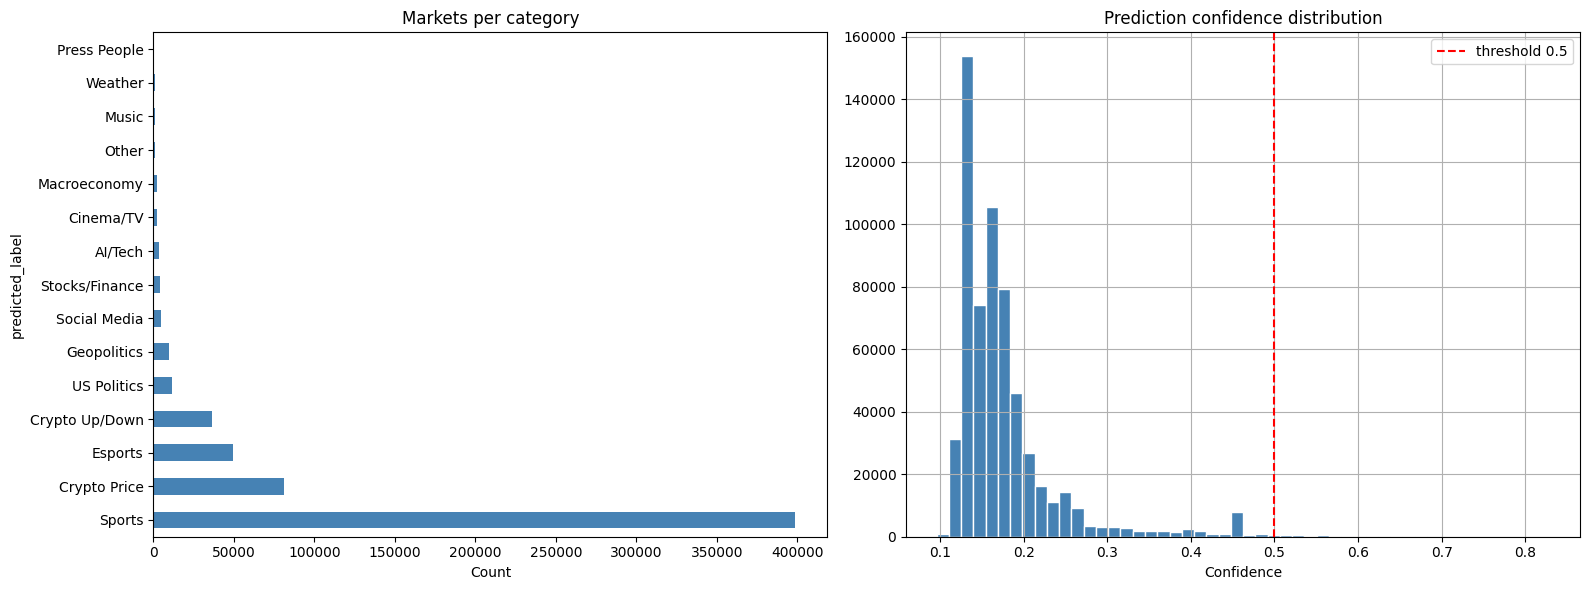

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution des catégories
all_markets['predicted_label'].value_counts().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Markets per category')
axes[0].set_xlabel('Count')

# Distribution de la confidence
all_markets['confidence'].hist(
    bins=50, ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Prediction confidence distribution')
axes[1].set_xlabel('Confidence')
axes[1].axvline(0.5, color='red', linestyle='--', label='threshold 0.5')
axes[1].legend()

plt.tight_layout()
plt.show()

## Étape 6 — Sauvegarder les résultats

In [12]:
# Upload vers BigQuery
table_id = 'polymarket-research-490517.polymarket.markets_classified'

job_config = bigquery.LoadJobConfig(
    write_disposition='WRITE_TRUNCATE'  # écrase si existe déjà
)

job = client.load_table_from_dataframe(
    all_markets[['question', 'slug', 'event_slug', 'predicted_label', 'confidence']],
    table_id,
    job_config=job_config,
)
job.result()
print(f"Uploaded {len(all_markets)} rows to {table_id}")

Uploaded 607561 rows to polymarket-research-490517.polymarket.markets_classified


In [13]:
# (Optionnel) Exporter en CSV aussi
all_markets.to_csv('markets_classified.csv', index=False)
files.download('markets_classified.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## ⚠️ Points d'attention

| Problème | Solution |
|---|---|
| F1 macro < 0.75 à la cell CV | Les catégories Press People, Weather, Music ont trop peu d'exemples (1-3). Merge dans Other ou ajoute 10-20 exemples chacune. |
| Erreurs récurrentes au spot-check | Ajoute des exemples ciblés au training set et relance. |
| Le bigram TF-IDF est la clé | "Super Bowl", "Up or Down" sont des bigrams distinctifs — c'est pour ça que `ngram_range=(1,2)` est important. |